In [1]:
import torch 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import os
outdir = r"C:\Document\Serieux\Travail\python_work\cEBNM_torch\notebooks\cEBMF_test\hierarchical_factor_model"
os.makedirs(outdir, exist_ok=True)
# Reproducibility


In [2]:
#torch.manual_seed(1)
N = 2000  
P= 200
# Scatter of x vs y 
#torch.manual_seed(1)

# -------------------------
# 2) Generate f (3 x 200)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# -------------------------

t0 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t1 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t2 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t11 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t12 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t21 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t22 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1

a0 = t0 * torch.randn(P)
b1 = t1 * torch.randn(P)
b2 = t2 * torch.randn(P)
detla11= t11 *torch.randn(P)

detla12= t11 *torch.randn(P)
detla21= t11 *torch.randn(P)
detla22= t11 *torch.randn(P)  
f_mat = torch.stack([a0,b1,b2, detla11, detla12,detla21, detla22 ], dim=0)
f_mat

tensor([[ 0.0394, -0.0000, -1.9349,  ...,  0.0000, -0.4920,  0.1506],
        [ 0.0000, -0.0000, -0.0000,  ...,  0.9365,  0.0216,  0.4761],
        [-0.0000, -1.3529,  0.0000,  ...,  1.7884, -0.0000, -0.7028],
        ...,
        [ 0.0000, -0.0000, -0.0000,  ...,  1.1708, -0.3762, -0.0000],
        [-0.0000,  0.0000, -0.0000,  ...,  1.0296,  0.4360,  0.0000],
        [ 0.0000, -0.0000,  0.0000,  ...,  0.3340, -1.0324,  0.0000]])

In [3]:

N= 1000

L = torch.zeros(N, 7, dtype=torch.float32)


L[:,0]=1
L[0:500, 1]=1

L [500:,2]=1
L[0:250,3]=1
L[251:500,4]=1

L[501:750,5]=1

L[751:,6]=1

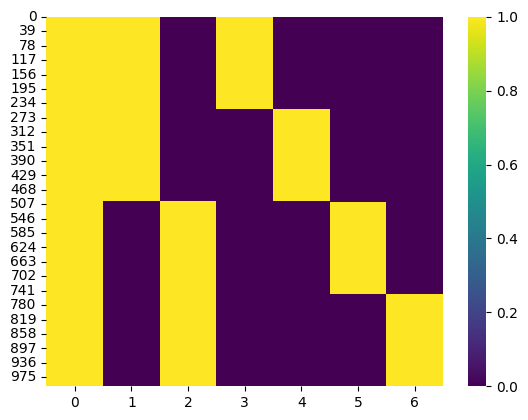

In [4]:


sns.heatmap(L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()


In [5]:
L.shape

torch.Size([1000, 7])

In [6]:
L 

tensor([[1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [1., 0., 1.,  ..., 0., 0., 1.],
        [1., 0., 1.,  ..., 0., 0., 1.],
        [1., 0., 1.,  ..., 0., 0., 1.]])

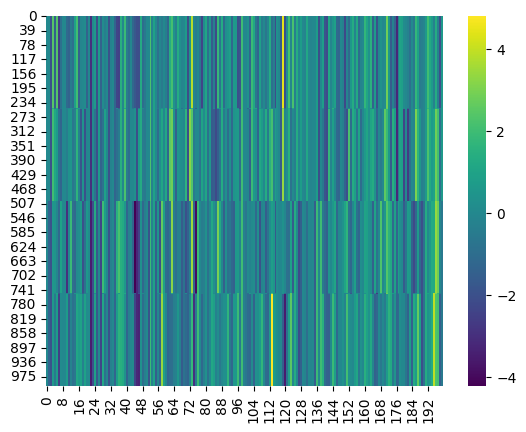

In [7]:
X_true= L@f_mat 
Z = L@f_mat + 0.5*torch.randn(N, P)  * 2.5  # (N, M)
Z_np = Z.detach().cpu().numpy()

# Save as tab-delimited text
np.savetxt(os.path.join(outdir, "Z_matrix.txt"), Z_np, fmt="%.6f", delimiter="\t")

X_true=    L@f_mat 
X_np = X_true.detach().cpu().numpy()

# Save as tab-delimited text
np.savetxt(os.path.join(outdir, "Z_matrix.txt"), Z_np, fmt="%.6f", delimiter="\t")
np.savetxt(os.path.join(outdir, "X_matrix.txt"), X_np, fmt="%.6f", delimiter="\t")
sns.heatmap(X_true , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

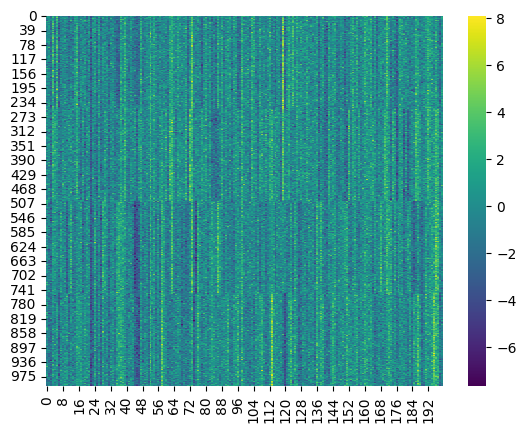

In [8]:
sns.heatmap(Z , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

In [9]:
from cebmf_torch import cEBMF

In [10]:
mycebmf0=  cEBMF(data=Z ,K=10 ) 
mycebmf0.initialise_factors()
mycebmf0.fit(20)

CEBMFResult(L=tensor([[-13.0108, -10.5012,   3.8918,  ...,   0.0000,   0.0000,   0.0000],
        [-11.5741,  -8.1356,   3.2138,  ...,   0.0000,   0.0000,   0.0000],
        [-13.2536,  -7.8126,   3.6344,  ...,   0.0000,   0.0000,   0.0000],
        ...,
        [-13.9422,   9.6330,  -4.8624,  ...,   0.0000,   0.0000,   0.0000],
        [-14.8655,   8.8068, -10.1749,  ...,   0.0000,   0.0000,   0.0000],
        [-16.1594,   7.3173,  -5.5526,  ...,   0.0000,   0.0000,   0.0000]]), F=tensor([[-5.3143e-04,  7.5934e-04,  9.9762e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 5.1223e-02, -6.5327e-02,  9.2075e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 1.4750e-01,  7.6601e-03, -8.6062e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-1.2552e-01,  7.1221e-02, -2.3476e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 8.6154e-02,  3.5870e-02,  6.9344e-02,  ...,  0.0000e+00,
          0.0000e+00,

In [11]:
mycebmf01=  cEBMF(data=Z, 
                 prior_L="gbinary", K=10,
                  allow_backfitting=False ) 
mycebmf01.initialise_factors()
  
mycebmf01.fit(20)

CEBMFResult(L=tensor([[1.2990e-23, 3.6040e-06, 9.1069e+00,  ..., 1.2990e-23, 1.2990e-23,
         1.2990e-23],
        [1.2990e-23, 2.4503e-05, 7.9094e+00,  ..., 1.2990e-23, 1.2990e-23,
         1.2990e-23],
        [1.2990e-23, 4.6664e-04, 8.4677e+00,  ..., 1.2990e-23, 1.2990e-23,
         1.2990e-23],
        ...,
        [1.2990e-23, 7.9668e+00, 1.3593e-02,  ..., 1.2990e-23, 1.2990e-23,
         1.2990e-23],
        [1.2990e-23, 8.2612e+00, 9.8243e-06,  ..., 1.2990e-23, 1.2990e-23,
         1.2990e-23],
        [1.2990e-23, 7.8839e+00, 4.2829e-01,  ..., 1.2990e-23, 1.2990e-23,
         1.2990e-23]]), F=tensor([[ 6.6850e-15,  1.6136e-03,  1.2054e-03,  ...,  6.6863e-15,
          6.6863e-15,  6.6863e-15],
        [-7.6322e-16, -1.6547e-01,  5.1279e-04,  ..., -7.6176e-16,
         -7.6176e-16, -7.6176e-16],
        [-1.4387e-15, -1.2484e-01, -1.1782e-01,  ..., -1.4301e-15,
         -1.4301e-15, -1.4301e-15],
        ...,
        [ 1.1892e-15,  3.2484e-01,  2.7220e-02,  ...,  1.1908e-15

In [12]:
 
mycebmf2=  cEBMF(data=Z,self_row_cov=True,
                 prior_L="cgb_sharp", K=10,
                  allow_backfitting=False ) 
mycebmf2.initialise_factors()
 
mycebmf2.fit(20)

[CGB] Epoch 10/10, Loss=20.5749, mu2=-0.080, sigma2=1.840
[CGB] Epoch 10/10, Loss=16.0254, mu2=-0.035, sigma2=1.294
[CGB] Epoch 10/10, Loss=10.0021, mu2=-0.013, sigma2=0.882
[CGB] Epoch 10/10, Loss=8.9790, mu2=-0.024, sigma2=0.807
[CGB] Epoch 10/10, Loss=2.2362, mu2=-0.001, sigma2=0.190
[CGB] Epoch 10/10, Loss=2.2086, mu2=0.002, sigma2=0.189
[CGB] Epoch 10/10, Loss=2.1853, mu2=-0.002, sigma2=0.228
[CGB] Epoch 10/10, Loss=2.1601, mu2=0.004, sigma2=0.205
[CGB] Epoch 10/10, Loss=2.1523, mu2=0.006, sigma2=0.261
[CGB] Epoch 10/10, Loss=2.1447, mu2=0.004, sigma2=0.255
[CGB] Epoch 10/10, Loss=19.5555, mu2=-0.160, sigma2=1.308
[CGB] Epoch 10/10, Loss=14.7560, mu2=-0.077, sigma2=0.726
[CGB] Epoch 10/10, Loss=8.1086, mu2=-0.025, sigma2=0.352
[CGB] Epoch 10/10, Loss=6.8962, mu2=-0.063, sigma2=0.316
[CGB] Epoch 10/10, Loss=3.1655, mu2=-0.002, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.9540, mu2=0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=3.3815, mu2=-0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.9624,

CEBMFResult(L=tensor([[-0.8441, -0.4641,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.8441, -0.4640,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.8441, -0.4639,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [-0.8441,  0.0000, -0.2436,  ...,  0.0000,  0.0000,  0.0000],
        [-0.8441,  0.0000, -0.2436,  ...,  0.0000,  0.0000,  0.0000],
        [-0.8441,  0.0000, -0.2436,  ...,  0.0000,  0.0000,  0.0000]]), F=tensor([[-4.4186e-03,  1.6819e-03,  5.4344e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 1.4980e+00, -2.7181e+00,  2.4137e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.3144e+00,  1.4950e-03,  3.3474e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-3.1912e+00,  6.5519e+00,  2.9293e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 4.0000e-03,  4.4474e+00,  6.9222e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 6.7354e-01,

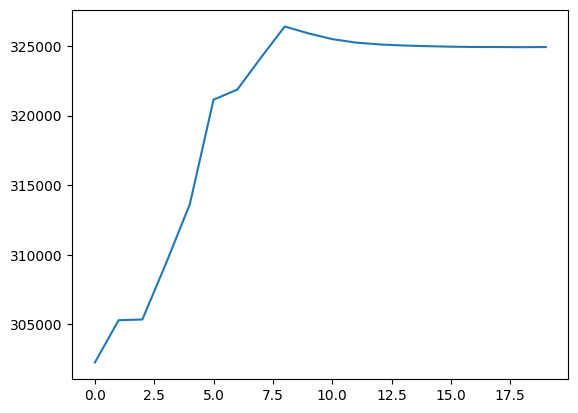

In [13]:
plt.plot(mycebmf2.obj)

In [14]:
k=0
#mycebmf2._update_factors(k)

In [15]:
 
mycebmf21=  cEBMF(data=Z,self_row_cov=True,
                 prior_L="emdn", K=10,
                  allow_backfitting=False ) 
mycebmf21.initialise_factors()
 
  
mycebmf21.fit(20)

[EMDN] Epoch 10/10, Loss: 19.7599
[EMDN] Epoch 10/10, Loss: 10.0924
[EMDN] Epoch 10/10, Loss: 5.4135
[EMDN] Epoch 10/10, Loss: 5.3900
[EMDN] Epoch 10/10, Loss: 2.0055
[EMDN] Epoch 10/10, Loss: 1.9959
[EMDN] Epoch 10/10, Loss: 1.9811
[EMDN] Epoch 10/10, Loss: 1.9655
[EMDN] Epoch 10/10, Loss: 1.9655
[EMDN] Epoch 10/10, Loss: 1.9565
[EMDN] Epoch 10/10, Loss: 4.6679
[EMDN] Epoch 10/10, Loss: 4.0293
[EMDN] Epoch 10/10, Loss: 2.9707
[EMDN] Epoch 10/10, Loss: 2.8299
[EMDN] Epoch 10/10, Loss: 2.0092
[EMDN] Epoch 10/10, Loss: 1.9620
[EMDN] Epoch 10/10, Loss: 1.9640
[EMDN] Epoch 10/10, Loss: 1.9825
[EMDN] Epoch 10/10, Loss: 1.9062
[EMDN] Epoch 10/10, Loss: 1.9399
[EMDN] Epoch 10/10, Loss: 3.6776
[EMDN] Epoch 10/10, Loss: 3.5247
[EMDN] Epoch 10/10, Loss: 2.8349
[EMDN] Epoch 10/10, Loss: 2.6700
[EMDN] Epoch 10/10, Loss: 1.9917
[EMDN] Epoch 10/10, Loss: 1.9694
[EMDN] Epoch 10/10, Loss: 1.9841
[EMDN] Epoch 10/10, Loss: 1.9536
[EMDN] Epoch 10/10, Loss: 1.8956
[EMDN] Epoch 10/10, Loss: 1.9179
[EMDN] E

CEBMFResult(L=tensor([[ -9.9860,  -7.4888,   1.4877,  ...,  -2.5744,   1.4486,   0.0937],
        [ -9.6254,  -7.5405,   1.6043,  ...,  -2.4512,   0.3393,   0.7858],
        [ -9.7959,  -7.5070,   1.4306,  ...,  -1.2653,   0.8999,  -0.1464],
        ...,
        [-11.1891,   6.8272,  -5.7184,  ...,  -0.1166,  -0.2777,   1.3604],
        [-11.0916,   6.8659,  -6.2298,  ...,  -0.9154,  -0.3678,   0.3334],
        [-12.1589,   6.9511,  -5.4968,  ...,   1.3064,   1.2826,  -1.8604]]), F=tensor([[-7.7109e-04,  7.8723e-04,  2.6730e-03,  ..., -8.2052e-02,
          4.7259e-03, -9.8657e-02],
        [ 6.2881e-02, -8.0446e-02,  6.9559e-04,  ...,  4.0834e-02,
          2.0615e-01,  1.7032e-03],
        [ 1.8712e-01,  1.8645e-02,  1.0814e-04,  ..., -1.0495e-02,
          4.6039e-02, -1.0437e-01],
        ...,
        [-1.5171e-01,  9.2298e-02,  2.2123e-03,  ...,  2.0356e-04,
          6.6070e-03, -7.3131e-03],
        [ 1.1733e-01,  5.8123e-02,  1.0722e-01,  ...,  9.4009e-02,
         -1.2545e-03,

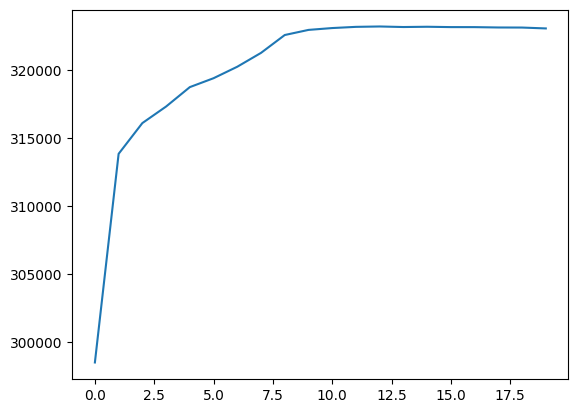

In [16]:
plt.plot(mycebmf21.obj)

In [17]:
 
mycebmf1=  cEBMF(data=Z,self_row_cov=True,
                 prior_L="cgb", K=10,
                  allow_backfitting=False ) 
mycebmf1.initialise_factors()
 
  
mycebmf1.fit(20)

[CGB] Epoch 10/10, Loss=4.9638, mu2=-0.080, sigma2=13.272
[CGB] Epoch 10/10, Loss=4.5898, mu2=-0.045, sigma2=9.071
[CGB] Epoch 10/10, Loss=3.9978, mu2=-0.009, sigma2=6.052
[CGB] Epoch 10/10, Loss=3.8750, mu2=-0.029, sigma2=5.640
[CGB] Epoch 10/10, Loss=2.1582, mu2=-0.001, sigma2=2.774
[CGB] Epoch 10/10, Loss=2.1241, mu2=0.012, sigma2=2.970
[CGB] Epoch 10/10, Loss=2.1058, mu2=-0.002, sigma2=2.920
[CGB] Epoch 10/10, Loss=2.0988, mu2=-0.000, sigma2=2.948
[CGB] Epoch 10/10, Loss=2.0902, mu2=0.009, sigma2=2.624
[CGB] Epoch 10/10, Loss=2.0730, mu2=-0.012, sigma2=2.734
[CGB] Epoch 10/10, Loss=4.9574, mu2=-0.160, sigma2=13.188
[CGB] Epoch 10/10, Loss=4.5875, mu2=-0.079, sigma2=9.063
[CGB] Epoch 10/10, Loss=3.9122, mu2=-0.013, sigma2=6.306
[CGB] Epoch 10/10, Loss=3.7147, mu2=-0.050, sigma2=6.070
[CGB] Epoch 10/10, Loss=2.0066, mu2=0.016, sigma2=3.593
[CGB] Epoch 10/10, Loss=1.9618, mu2=0.042, sigma2=4.008
[CGB] Epoch 10/10, Loss=1.9555, mu2=0.012, sigma2=3.758
[CGB] Epoch 10/10, Loss=1.9014, mu

CEBMFResult(L=tensor([[-12.8985, -10.1343,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [-11.4839,  -7.8576,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [-13.1704,  -7.5409,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        ...,
        [-13.8894,   9.2323,  -5.6518,  ...,   0.0000,   0.0000,   0.0000],
        [-14.5949,   8.2537,  -9.7750,  ...,   0.0000,   0.0000,   0.0000],
        [-16.0144,   6.9020,  -5.8451,  ...,   0.0000,   0.0000,   0.0000]]), F=tensor([[-5.4836e-04,  7.8535e-04,  2.0896e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 5.1854e-02, -6.7659e-02,  1.2066e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 1.4790e-01,  8.2081e-03,  4.6760e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-1.2712e-01,  7.2481e-02,  4.6763e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 8.5308e-02,  3.7287e-02,  1.0353e-01,  ...,  0.0000e+00,
          0.0000e+00,

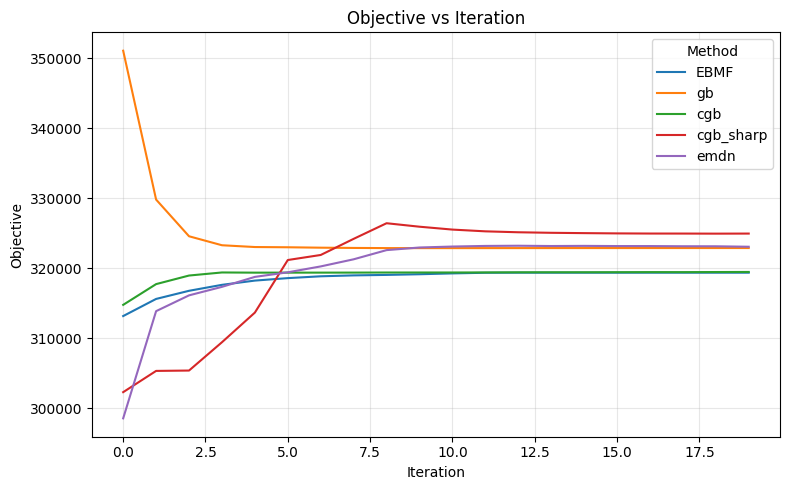

In [18]:
import matplotlib.pyplot as plt
def to1d(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().flatten().numpy()
    return np.asarray(a).ravel()

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(to1d(mycebmf0.obj), label="EBMF")
ax.plot(to1d(mycebmf01.obj), label="gb")
ax.plot(to1d(mycebmf1.obj), label="cgb")
ax.plot(to1d(mycebmf2.obj),  label="cgb_sharp")

ax.plot(to1d(mycebmf21.obj),  label="emdn")

ax.set_title("Objective vs Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
ax.legend(title="Method", loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
mycebmf1.F

tensor([[-5.4836e-04,  7.8535e-04,  2.0896e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 5.1854e-02, -6.7659e-02,  1.2066e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 1.4790e-01,  8.2081e-03,  4.6760e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-1.2712e-01,  7.2481e-02,  4.6763e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 8.5308e-02,  3.7287e-02,  1.0353e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 3.6301e-05, -6.7139e-02, -3.1739e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])

(array([ 64., 149.,  36.,   0., 501.,   0.,   2.,  72., 147.,  29.]),
 array([-9.65702343, -7.59979248, -5.54256201, -3.48533154, -1.42810059,
         0.62913036,  2.68636036,  4.74359131,  6.80082226,  8.85805225,
        10.91528416]),
 <BarContainer object of 10 artists>)

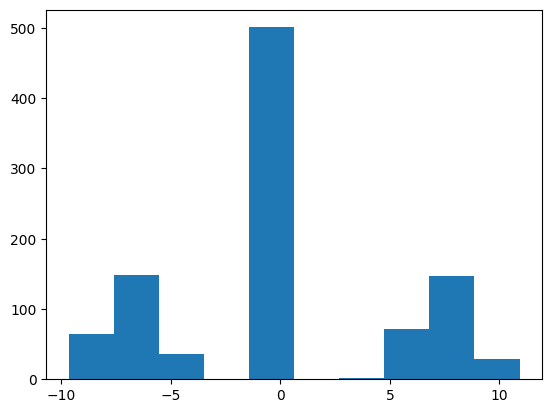

In [20]:
plt.hist(mycebmf1.L[:,3 ])


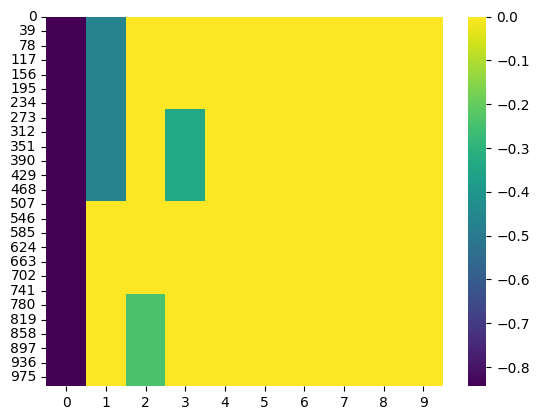

In [21]:
sns.heatmap(mycebmf2.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

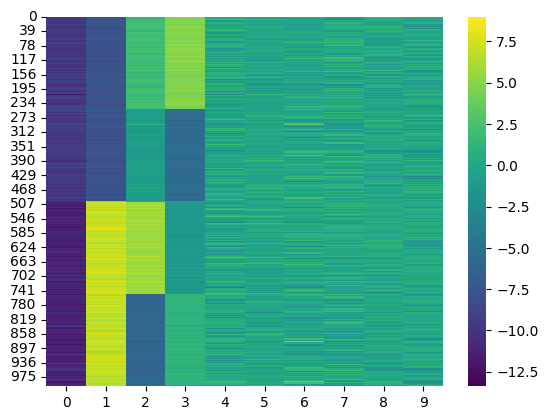

In [22]:
 
sns.heatmap(mycebmf21.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

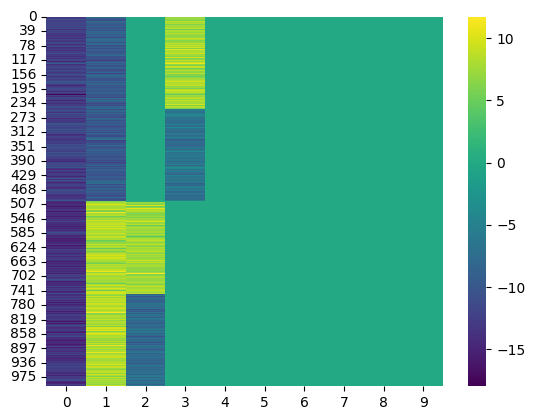

In [23]:
 
sns.heatmap(mycebmf1.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

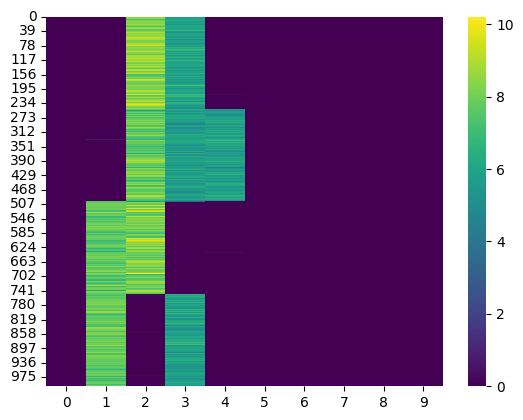

In [24]:
sns.heatmap(mycebmf01.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

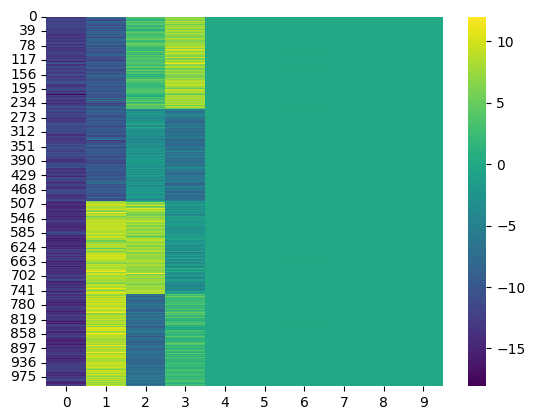

In [25]:
sns.heatmap(mycebmf0.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

In [26]:
mycebmf1.L[:,4]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

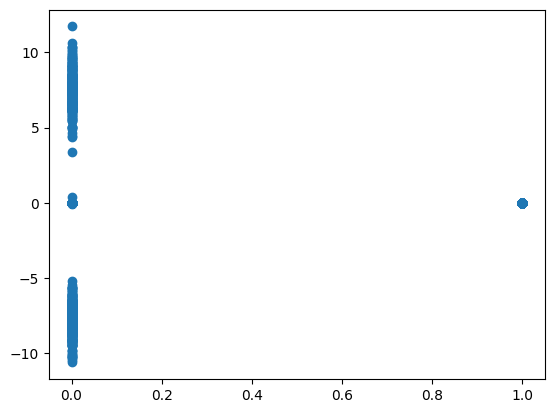

In [27]:
plt.scatter(L[:,3],mycebmf1.L[:,2])

(array([   0.,    0.,    0.,    0.,    0., 1000.,    0.,    0.,    0.,
           0.]),
 array([-0.5       , -0.40000001, -0.30000001, -0.19999999, -0.09999999,
         0.        ,  0.10000002,  0.19999999,  0.30000001,  0.40000004,
         0.5       ]),
 <BarContainer object of 10 artists>)

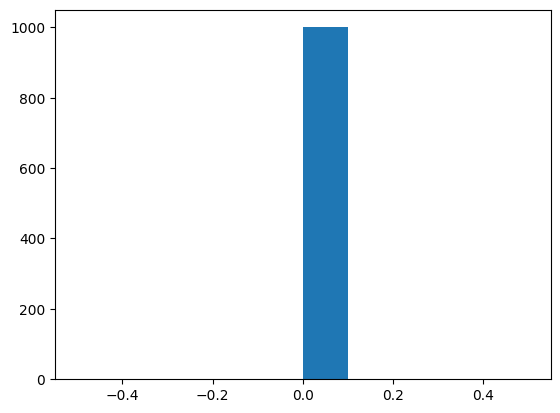

In [28]:
plt.hist(mycebmf1.L[:,4 ])

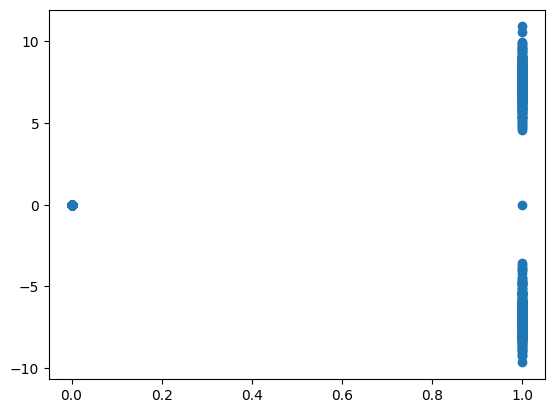

In [29]:
plt.scatter(L[:,1],mycebmf1.L[:,3])

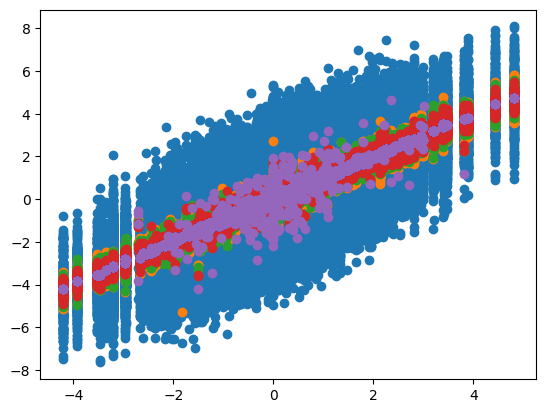

In [34]:
plt.scatter(L@f_mat,Z)
plt.scatter(L@f_mat,mycebmf0.L@mycebmf0.F.T )
plt.scatter(L@f_mat,mycebmf1.L@mycebmf1.F.T )


plt.scatter(L@f_mat,mycebmf01.L@mycebmf01.F.T )
plt.scatter(L@f_mat,mycebmf2.L@ mycebmf2.F.T )

In [31]:
print(torch.mean( (L@f_mat - mycebmf0.L@ mycebmf0.F.T )**2))
print(torch.mean((L@f_mat - mycebmf1.L@ mycebmf1.F.T )**2))
print(torch.mean((L@f_mat - mycebmf2.L@ mycebmf2.F.T )**2)) 

print(torch.mean((L@f_mat - mycebmf01.L@ mycebmf01.F.T )**2))

tensor(0.0369)
tensor(0.0292)
tensor(0.0074)
tensor(0.0183)


In [32]:
print(torch.mean( (L@f_mat - mycebmf0.L@ mycebmf0.F.T )**2))
print(torch.mean((L@f_mat - mycebmf1.L@ mycebmf1.F.T )**2))
print(torch.mean((L@f_mat - mycebmf2.L@ mycebmf2.F.T )**2)) 

print(torch.mean((L@f_mat - mycebmf01.L@ mycebmf01.F.T )**2))

tensor(0.0369)
tensor(0.0292)
tensor(0.0074)
tensor(0.0183)


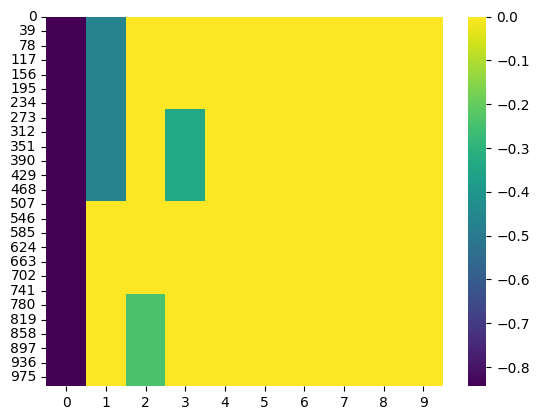

In [33]:
sns.heatmap(mycebmf2.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()